In [7]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42

In [15]:
df_combined = pd.read_parquet("data/df_combined.parquet")
print(df_combined.shape)
df_combined.head()

(30557, 49)


,Place_ID,Date,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,L3_NO2_sensor_altitude,L3_NO2_stratospheric_NO2_column_number_density,L3_NO2_tropopause_pressure,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_O3_O3_effective_temperature,...,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,wind_speed,wind_direction,wind_dir_sin,wind_dir_cos,split
0,010Q650,2020-01-02,-1.231330,0.006507,840209.874619,0.000057,6156.074219,0.000017,0.119095,234.151102,...,11.000000,60.200001,18.516840,1.996377,-1.227395,2.343506,328.416332,-0.523743,0.851876,train
1,010Q650,2020-01-03,-1.082553,0.018360,840772.941995,0.000055,6156.074219,0.000021,0.115179,233.313706,...,14.600000,48.799999,22.546533,3.330430,-1.188108,3.536009,340.366491,-0.336002,0.941861,train
2,010Q650,2020-01-04,-1.001242,0.015904,841410.713456,0.000059,7311.869141,0.000007,0.115876,232.233484,...,16.400000,33.400002,27.031030,5.065727,3.500559,6.157557,34.645557,0.568498,0.822685,train
3,010Q650,2020-01-05,-0.777019,0.055765,841103.242368,0.000060,11205.388333,0.000023,0.141557,230.936229,...,6.911948,21.300001,23.971857,3.004001,1.099468,3.198883,20.102680,0.343704,0.939078,train
4,010Q650,2020-01-06,0.366323,0.028530,840763.055499,0.000062,11205.372845,0.000009,0.126369,232.499132,...,13.900001,44.700001,16.816309,2.621787,2.670559,3.742413,45.527997,0.713593,0.700561,train


In [16]:
train_mask = df_combined.split == 'train'
val_mask = df_combined.split == 'val'
assert set(df_combined.loc[train_mask, 'Place_ID']) & set(df_combined.loc[val_mask, 'Place_ID']) == set()

X_train = df_combined.loc[train_mask].drop(columns=['target','split', 'Place_ID', 'Date'])
y_train = df_combined.loc[train_mask, 'target']
X_val   = df_combined.loc[val_mask].drop(columns=['target','split', 'Place_ID', 'Date'])
y_val   = df_combined.loc[val_mask, 'target']

X_train.shape

(24546, 45)

## Baseline Model - Dummy Model

In [8]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(np.zeros((len(y_train), 1)), y_train)  # Features irrelevant, Dummy ignoriert X komplett
y_pred = dummy.predict(np.zeros((len(y_val), 1)))

baseline_rmse = mean_squared_error(y_val, y_pred, squared=False)
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 42.12


## Building the model

### Pipeline

In [ ]:
pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),                 # RF needs no NaNs
    ('rf',     RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])
# Note: no scaler — tree models don't need feature scaling.

### Grid search, K-fold and fit

In [18]:
param_grid = {
    'rf__n_estimators':     [200, 400],
    'rf__max_depth':        [None, 15, 25],
    'rf__min_samples_leaf': [1, 2, 5],
    'rf__max_features':     ['sqrt', 0.5],
}

cv = GroupKFold(n_splits=5)   # 5 folds, no Place_ID shared between folds

grid = GridSearchCV(
    pipe, param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',   # RMSE (sklearn maximizes, so it's negated)
    n_jobs=-1,
    verbose=2,
)
groups = df_combined.loc[df_combined.split == 'train', 'Place_ID']
grid.fit(X_train, y_train, groups=groups) 

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__n_estimators=200; total time=  19.6s
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__n_estimators=200; total time=  20.3s
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__n_estimators=200; total time=  20.6s
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__n_estimators=200; total time=  20.7s
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__n_estimators=200; total time=  21.0s
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__n_estimators=200; total time=  19.0s
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__n_estimators=400; total time=  40.5s
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__n_estimators=400; total time=  40.6s
[C

GridSearchCV(cv=GroupKFold(n_splits=5),
             estimator=Pipeline(steps=[('impute',
                                        SimpleImputer(strategy='median')),
                                       ('rf',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [None, 15, 25],
                         'rf__max_features': ['sqrt', 0.5],
                         'rf__min_samples_leaf': [1, 2, 5],
                         'rf__n_estimators': [200, 400]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [19]:
print('Best params:   ', grid.best_params_)
print('Best CV RMSE:  ', round(-grid.best_score_, 2))   # un-negate

Best params:    {'rf__max_depth': None, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 400}
Best CV RMSE:   34.39


In [22]:
pred = grid.predict(X_val)

print(f'VAL RMSE: {np.sqrt(mean_squared_error(y_val, pred)):.2f}')

VAL RMSE: 30.97


## Model tunning

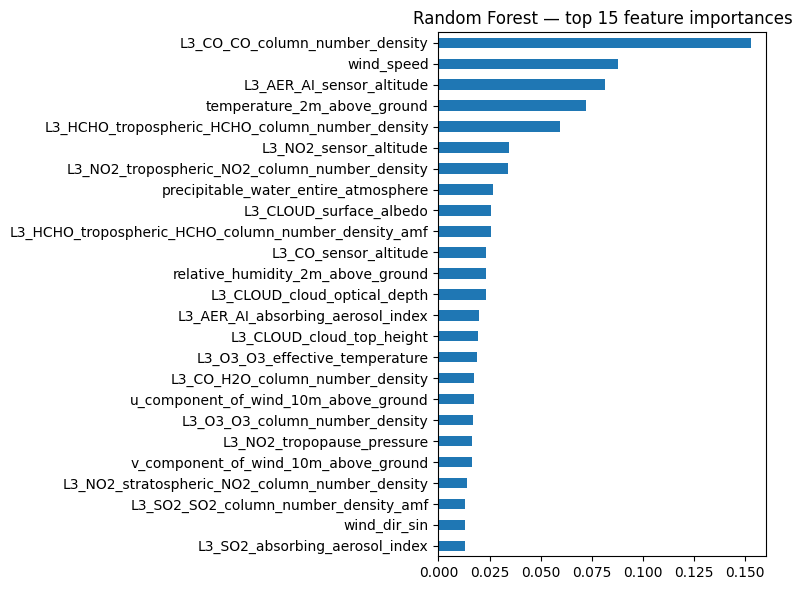

In [25]:
best_rf = grid.best_estimator_.named_steps['rf']
imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

imp.head(25).plot.barh(figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title('Random Forest — top 15 feature importances')
plt.tight_layout()
plt.show()

In [24]:
from sklearn.base import clone

# Feature importances from the tuned model (grid must already be fitted)
best_rf = grid.best_estimator_.named_steps['rf']
importances = pd.Series(best_rf.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False)

def run_with_top_n(n):
    cols  = importances.head(n).index.tolist()
    model = clone(grid.best_estimator_)          # same pipeline + best params
    model.fit(X_train[cols], y_train)
    pred  = model.predict(X_val[cols])
    rmse  = np.sqrt(mean_squared_error(y_val, pred))
    print(f'top {n:>2} features -> VAL RMSE = {rmse:.2f}')
    return rmse, cols

# Baseline: all features, for comparison
all_pred = grid.predict(X_val)
print(f'all {X_train.shape[1]} features -> VAL RMSE = {np.sqrt(mean_squared_error(y_val, all_pred)):.2f}')

# Top 15 and top 25
rmse15, cols15 = run_with_top_n(15)
rmse25, cols25 = run_with_top_n(25)

all 45 features -> VAL RMSE = 30.97
top 15 features -> VAL RMSE = 31.80
top 25 features -> VAL RMSE = 31.03


### Gradient Boosting

In [37]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

In [38]:
gb = HistGradientBoostingRegressor(random_state=RANDOM_STATE)   # handles NaNs natively

gb_log = TransformedTargetRegressor(regressor=gb, func=np.log1p, inverse_func=np.expm1)

param_grid = {
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth':     [None, 6, 10],
    'regressor__max_iter':      [300, 600],
}

cv = GroupKFold(n_splits=5)
grid_gb = GridSearchCV(gb_log, param_grid, cv=cv,
                       scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=2)
grid_gb.fit(X_train, y_train, groups=groups)

print('best params:', grid_gb.best_params_)
print('best CV RMSE:', round(-grid_gb.best_score_, 2))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END regressor__learning_rate=0.05, regressor__max_depth=None, regressor__max_iter=300; total time=   3.8s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=None, regressor__max_iter=300; total time=   4.0s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=None, regressor__max_iter=300; total time=   4.0s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=None, regressor__max_iter=300; total time=   4.1s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=None, regressor__max_iter=300; total time=   4.1s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=None, regressor__max_iter=600; total time=   7.0s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=None, regressor__max_iter=600; total time=   7.1s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=None, regressor__max_iter=600; total time=   7.4s
[CV] END regressor__learning_rate=0.05, regressor__

In [39]:
def score(name, model):
    pred = np.clip(model.predict(X_val), 0, None)     # PM2.5 can't be negative
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae  = mean_absolute_error(y_val, pred)
    r2   = r2_score(y_val, pred)
    print(f'{name:22} RMSE={rmse:6.2f}  MAE={mae:6.2f}  R2={r2:6.3f}')
    return rmse

score('RandomForest (tuned)', grid)        # your earlier RF grid
score('HistGradientBoosting', grid_gb)

RandomForest (tuned)   RMSE= 30.97  MAE= 21.80  R2= 0.453
HistGradientBoosting   RMSE= 31.77  MAE= 21.06  R2= 0.425


31.765431578474118